In [1]:
import torch
import pandas as pd

from src.model import MultimodalFakeNewsDetectionModel
from src.dataloader import create_dataloader

W0718 17:37:13.702000 20224 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


CUDA Available: True


In [2]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)

if device.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))

PyTorch Version : 2.13.0+cu126
CUDA Available  : True
Using Device : cuda
GPU : NVIDIA GeForce RTX 2050


In [3]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4

In [4]:


train_embeddings = torch.load(
    "./data/embeddings/train_embeddings.pt"
)

validation_embeddings = torch.load(
    "./data/embeddings/validation_embeddings.pt"
)

test_embeddings = torch.load(
    "./data/embeddings/test_embeddings.pt"
)

train_loader = create_dataloader(
    csv_path="./data/processed/train_clean.csv",
    embeddings=train_embeddings,
    shuffle=True,
)

val_loader = create_dataloader(
    csv_path="./data/processed/validation_clean.csv",
    embeddings=validation_embeddings,
    shuffle=False,
)
test_loader = create_dataloader(
    csv_path="./data/processed/test_clean.csv",
    embeddings=test_embeddings,
    shuffle=False,
)

In [5]:
sample = next(iter(train_loader))

print(sample["text"].shape)
print(sample["image"].shape)
print(sample["label"].shape)

torch.Size([32, 768])
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [6]:
print(len(train_embeddings))

31296


In [7]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['id', 'text', 'image', 'label'])


In [8]:
model = MultimodalFakeNewsDetectionModel()

print(model)

MultimodalFakeNewsDetectionModel(
  (model): JointTextImageModel(
    (text_module): Linear(in_features=768, out_features=300, bias=True)
    (image_module): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
model = model.to(device)

print(next(model.parameters()).device)

cuda:0


In [10]:
optimizer = model.configure_optimizers()

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [11]:
criterion = torch.nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [12]:
batch = next(iter(train_loader))

text = batch["text"].to(device)
image = batch["image"].to(device)
label = batch["label"].to(device)

model.eval()

with torch.no_grad():
    pred, loss = model(text, image, label)

print("Prediction shape:", pred.shape)
print("Loss:", loss.item())

c:\Users\suraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Prediction shape: torch.Size([32, 2])
Loss: 0.693673312664032


In [13]:
import torch
import pytorch_lightning as pl

from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
)

In [14]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="best-model",
)

In [15]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
)

In [16]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[
        checkpoint_callback,
        early_stop_callback,
    ],
    log_every_n_steps=10,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\suraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [18]:
trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model │ JointTextImageModel │ 59.6 M │ eval │     0 │
└───┴───────┴─────────────────────┴────────┴──────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 58.1 M                                                                                       
Total params: 59.6 M                                                                                               
Total estimated model params size (MB): 238.242                                                                    
Modules in train mode: 0                                                                                           
Modules in eval mode: 430                                                                                          
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [17]:
best_model = MultimodalFakeNewsDetectionModel.load_from_checkpoint(
    "lightning_logs/version_0/checkpoints/best-model.ckpt"
)

In [18]:
trainer.test(
    model=best_model,
    dataloaders=test_loader,
)

You are using a CUDA device ('NVIDIA GeForce RTX 2050') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\suraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\suraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8129478096961975     │
│         test_loss         │    0.4153093695640564     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.4153093695640564, 'test_acc': 0.8129478096961975}]

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
y_true = best_model.test_labels
y_pred = best_model.test_preds
y_prob = best_model.test_probs

In [21]:
print(len(y_true))
print(len(y_pred))
print(len(y_prob))

3908
3908
3908


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Real", "Fake"]
))

Accuracy : 0.8129
Precision: 0.8111
Recall   : 0.8652
F1 Score : 0.8373

Classification Report

              precision    recall  f1-score   support

        Real       0.82      0.75      0.78      1734
        Fake       0.81      0.87      0.84      2174

    accuracy                           0.81      3908
   macro avg       0.81      0.81      0.81      3908
weighted avg       0.81      0.81      0.81      3908



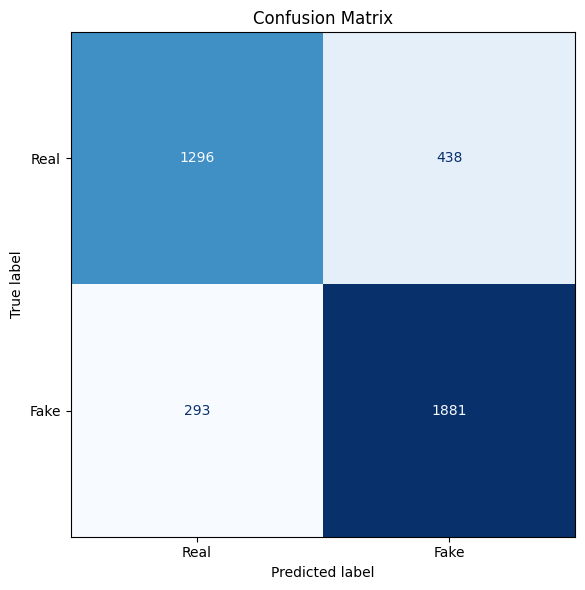

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

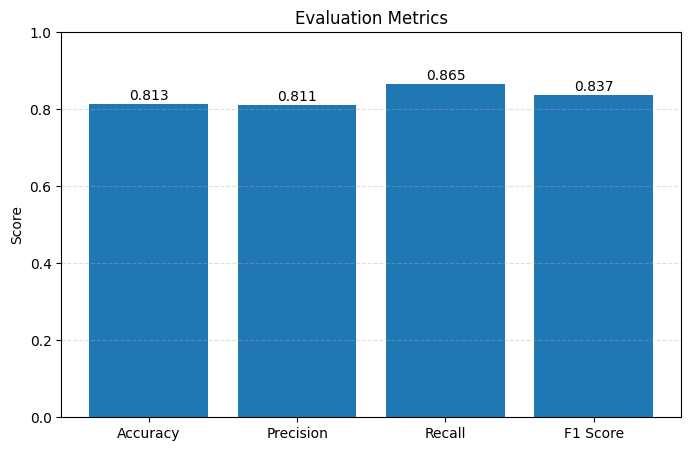

In [24]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
}

plt.figure(figsize=(8,5))

bars = plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Evaluation Metrics")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.3f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

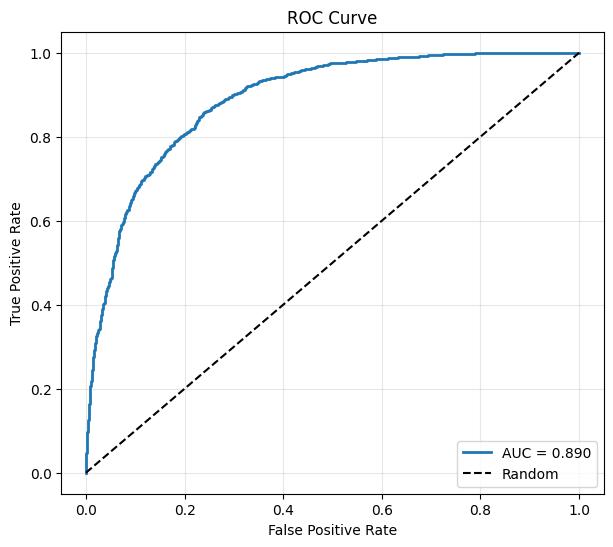

AUC: 0.8902349673025767


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(y_true, y_prob)
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

print("AUC:", auc)

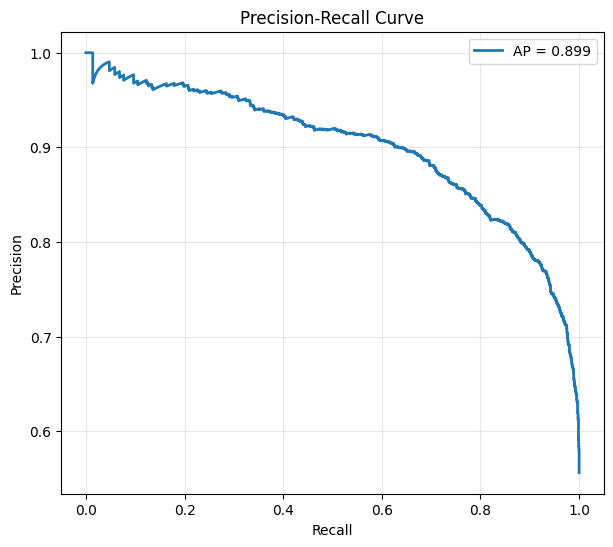

Average Precision: 0.8992697648172545
